In [359]:
import random
import json
import re
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.metrics import edit_distance

from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)


# Experiment 6 - MCQ Long answer HTML tags

For this experiment I changed the system prompt, asking the LLM to generate more text (about "thinking") and then give the final answer.


**Parameters:**
- model: llama3.1:8b
- system prompt: MCQ_system_prompt_v3.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)
- the output is limited to 128 tokens (shouldn't influence the results, it only cutoffs the generation)


Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [360]:
ground_truth = []

with open('../data/datasets/STAR_QA_and_stsg_val.json') as f:
    data = json.load(f)
    ground_truth = [{
        'id': sample['question_id'],
        'choices': sample['choices'],
        'num': sample['answer'],
        'text': sample['choices'][str(sample['answer'])]
    } for sample in data]


# we keep num as str so we can directrly access choices dictionaries
gt_df = pd.DataFrame(ground_truth).astype({'id': 'string', 'num': 'string', 'text': 'string'})
gt_df.set_index('id', inplace=True)
gt_df


,choices,num,text
id,,,
Interaction_T1_13,"{'0': 'The closet/cabinet.', '1': 'The blanket...",2,The clothes.
Interaction_T1_14,"{'0': 'The blanket.', '1': 'The table.', '2': ...",2,The clothes.
Interaction_T1_31,"{'0': 'The pillow.', '1': 'The bag.', '2': 'Th...",2,The clothes.
Interaction_T1_32,"{'0': 'The food.', '1': 'The shoe.', '2': 'The...",1,The shoe.
Interaction_T1_40,"{'0': 'The broom.', '1': 'The closet/cabinet.'...",1,The closet/cabinet.
...,...,...,...
Feasibility_T6_1453,"{'0': 'Wash the table.', '1': 'Take the box.',...",0,Wash the table.
Feasibility_T6_1454,"{'0': 'Take the towel.', '1': 'Throw the bag.'...",0,Take the towel.
Feasibility_T6_1455,"{'0': 'Throw the bag.', '1': 'Wash the table.'...",1,Wash the table.


In [361]:
models_pred = {}


## Llama3.1-3b

In [362]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/mcq_reasoning_llama3.2_20250210_20:17:23.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> To determine which object was tidi...
Interaction_T1_14,<Reasoning> To determine which object was tidi...
Interaction_T1_31,Error while generating the response. Look at t...
Interaction_T1_32,<Reasoning> To determine which object was put ...
Interaction_T1_40,<Reasoning> The question asks which object was...
...,...
Feasibility_T6_1453,<Reasoning> To determine what the person is ab...
Feasibility_T6_1454,"<Reasoning> To answer this question, we need t..."
Feasibility_T6_1455,"<Reasoning> To answer this question, we need t..."


In [363]:
predictions_df.shape


(7098, 1)

In [364]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


Answer following the template: 2100
29.59% of the total

Only 4998 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_2898940/110584183.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Let's start by viewing how many answers follow the template:

In [365]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/1456153070.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 6900
97.21% of the total

Only 198 samples do not contain the answer in the response with the specified format


In [366]:
predictions_df[predictions_df['contains_answer']]['answer']


id
Interaction_T1_13      <Reasoning>
To determine which object was tidi...
Interaction_T1_14      <Reasoning>
To determine which object was tidi...
Interaction_T1_32      <Reasoning>
To determine which object was put ...
Interaction_T1_40      <Reasoning>
The question asks which object was...
Interaction_T1_43      <Reasoning>
To determine which object was thro...
                                             ...                        
Feasibility_T6_1453    <Reasoning>
To determine what the person is ab...
Feasibility_T6_1454    <Reasoning>
To answer this question, we need t...
Feasibility_T6_1455    <Reasoning>
To answer this question, we need t...
Feasibility_T6_1456    <Reasoning>
To answer this question, we need t...
Feasibility_T6_1468    <Reasoning>
To answer this question, we need t...
Name: answer, Length: 6900, dtype: string

In [367]:
predictions_df["pred_text"] = ""
predictions_df


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> To determine which object was tidi...,True,True,
Interaction_T1_14,<Reasoning> To determine which object was tidi...,False,True,
Interaction_T1_31,Error while generating the response. Look at t...,False,False,
Interaction_T1_32,<Reasoning> To determine which object was put ...,False,True,
Interaction_T1_40,<Reasoning> The question asks which object was...,False,True,
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> To determine what the person is ab...,True,True,
Feasibility_T6_1454,"<Reasoning> To answer this question, we need t...",False,True,
Feasibility_T6_1455,"<Reasoning> To answer this question, we need t...",True,True,


In [368]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df 


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> To determine which object was tidi...,True,True,The clothes.
Interaction_T1_14,<Reasoning> To determine which object was tidi...,False,True,The clothes.
Interaction_T1_31,Error while generating the response. Look at t...,False,False,
Interaction_T1_32,<Reasoning> To determine which object was put ...,False,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks which object was...,False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> To determine what the person is ab...,True,True,Wash the table.
Feasibility_T6_1454,"<Reasoning> To answer this question, we need t...",False,True,Wipe the table.
Feasibility_T6_1455,"<Reasoning> To answer this question, we need t...",True,True,Take the shoe.


In [369]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [370]:
models_pred["Llama3.1:3b"] = predictions_df


## Llama3.1-8b

In [371]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_llama3.1:8b_20250219_13:49:44.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> To determine which object was tidi...
Interaction_T1_14,<Reasoning> To determine which object was tidi...
Interaction_T1_31,<Reasoning> To determine which object was thro...
Interaction_T1_32,<Reasoning> To determine which object was put ...
Interaction_T1_40,<Reasoning> The question asks which object was...
...,...
Feasibility_T6_1453,<Reasoning> The person is initially seen holdi...
Feasibility_T6_1454,<Reasoning> The person is initially standing i...
Feasibility_T6_1455,<Reasoning> The person is initially standing i...


In [372]:
predictions_df.shape


(7098, 1)

In [373]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


Answer following the template: 5038
70.98% of the total

Only 2060 samples do not contain the answer in the response with the specified format


/tmp/ipykernel_2898940/110584183.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Let's start by viewing how many answers follow the template:

In [374]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/1456153070.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 6543
92.18% of the total

Only 555 samples do not contain the answer in the response with the specified format


In [375]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> To determine which object was tidi...,True,True,The clothes.
Interaction_T1_14,<Reasoning> To determine which object was tidi...,False,True,The clothes.
Interaction_T1_31,<Reasoning> To determine which object was thro...,False,True,The clothes.
Interaction_T1_32,<Reasoning> To determine which object was put ...,True,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks which object was...,True,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> The person is initially seen holdi...,True,True,Put down the phone/camera.
Feasibility_T6_1454,<Reasoning> The person is initially standing i...,True,True,Throw the bag.
Feasibility_T6_1455,<Reasoning> The person is initially standing i...,False,True,Wash the table.


In [376]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [377]:
models_pred["Llama3.1:8b"] = predictions_df


## Deepseek-r1:1.5b

In [378]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_deepseek-r1:1.5b_20250218_18:07:17.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,"<think> Okay, so I'm trying to figure out this..."
Interaction_T1_14,"<think> Alright, let's tackle this question st..."
Interaction_T1_31,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_32,"<think> Okay, so I'm trying to figure out whic..."
Interaction_T1_40,"<think> Okay, so I'm trying to figure out this..."
...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what..."
Feasibility_T6_1454,"<think> Alright, let's tackle this question st..."
Feasibility_T6_1455,"<think> Okay, so I need to figure out what the..."


In [379]:
predictions_df.shape


(7098, 1)

In [380]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/110584183.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 3700
52.13% of the total

Only 3398 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [381]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/1456153070.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 5770
81.29% of the total

Only 1328 samples do not contain the answer in the response with the specified format


In [382]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df 


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,"<think> Okay, so I'm trying to figure out this...",True,True,The closet/cabinet.
Interaction_T1_14,"<think> Alright, let's tackle this question st...",False,True,The clothes.
Interaction_T1_31,"<think> Okay, so I need to figure out which ob...",True,True,The clothes.
Interaction_T1_32,"<think> Okay, so I'm trying to figure out whic...",True,True,The shoe.
Interaction_T1_40,"<think> Okay, so I'm trying to figure out this...",False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what...",False,True,Open the bag.
Feasibility_T6_1454,"<think> Alright, let's tackle this question st...",False,True,Hold the towel.
Feasibility_T6_1455,"<think> Okay, so I need to figure out what the...",False,False,


In [383]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [384]:
models_pred["deepseek-r1:1.5b"] = predictions_df


## Deepseek-r1:7b

In [385]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_deepseek-r1:7b_20250219_13:52:42.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_14,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_31,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_32,"<think> Okay, so I need to figure out which ob..."
Interaction_T1_40,"<think> Okay, so I need to figure out which ob..."
...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what..."
Feasibility_T6_1454,"<think> Okay, so I need to figure out what the..."
Feasibility_T6_1455,"<think> Alright, so I'm trying to figure out w..."


In [386]:
predictions_df.shape


(7098, 1)

In [387]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/110584183.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 2467
34.76% of the total

Only 4631 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [388]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/1456153070.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 6840
96.37% of the total

Only 258 samples do not contain the answer in the response with the specified format


In [389]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df 


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,"<think> Okay, so I need to figure out which ob...",False,True,The clothes.
Interaction_T1_14,"<think> Okay, so I need to figure out which ob...",False,True,The clothes.
Interaction_T1_31,"<think> Okay, so I need to figure out which ob...",True,True,The clothes.
Interaction_T1_32,"<think> Okay, so I need to figure out which ob...",True,True,The shoe.
Interaction_T1_40,"<think> Okay, so I need to figure out which ob...",False,True,The blanket.
...,...,...,...,...
Feasibility_T6_1453,"<think> Okay, so I'm trying to figure out what...",False,True,The table.
Feasibility_T6_1454,"<think> Okay, so I need to figure out what the...",False,True,Take the towel.
Feasibility_T6_1455,"<think> Alright, so I'm trying to figure out w...",False,True,The table.


In [390]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [391]:
models_pred["deepseek-r1:7b"] = predictions_df


## Phi3:3.8b

In [392]:
# needed to modify the output file because of the bug
# I introduced in the code
predictions = []
with open('../outputs/responses_phi3:3.8b_20250218_17:05:47.jsonl') as f:
    predictions = [json.loads(line) for line in f.readlines()]

# transforming the id key from `qid` to `id` for consistency and `response` to `answer`
predictions_df = pd.DataFrame(predictions, dtype='string').rename(columns={'qid':'id', 'response':'answer'})
predictions_df.set_index('id', inplace=True)
predictions_df


,answer
id,
Interaction_T1_13,<Reasoning> From the given Spatio-Temporal Sce...
Interaction_T1_14,<Reasoning> In the given Spatio-Temporal Scene...
Interaction_T1_31,<Reasoning> The given Spatio-Temporal Scene Gr...
Interaction_T1_32,<Reasoning> The sequence of Scene-Graphs shows...
Interaction_T1_40,<Reasoning> The question asks about an object ...
...,...
Feasibility_T6_1453,<Reasoning> From the given Spatio-Temporal Sce...
Feasibility_T6_1454,<Reasoning> From the Spatio-Temporal Scene Gra...
Feasibility_T6_1455,<Reasoning> The Scene-Graphs show that the per...


In [393]:
predictions_df.shape


(7098, 1)

In [394]:
# Check if the the template is somewhere in the answer
html_tags_pattern = r'<Final answer>\s*A:\s*\d\.\s*((?:\w+(?:\s|\/)?){,10}\.)\s*</Final answer>'
predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


print(f"Answer following the template: {predictions_df['html_tags_mask'] .value_counts()[True]}\n"
      f"{predictions_df['html_tags_mask'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['html_tags_mask'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/110584183.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['html_tags_mask']  = predictions_df['answer'].str.contains(html_tags_pattern, case=False, regex=True)


Answer following the template: 12
0.17% of the total

Only 7086 samples do not contain the answer in the response with the specified format


Let's start by viewing how many answers follow the template:

In [395]:
# Check if the the template is somewhere in the answer
#
# An example of the template expressed by the regex is: A: 1. The answer.
# where the number followed by a dot is optional
ans_regex_pattern = r'A:\s*(?:\d\.)?\s*((?:\w+(?:\s|\/)?){,10}\.)'
predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


print(f"Answer following the template: {predictions_df['contains_answer'] .value_counts()[True]}\n"
      f"{predictions_df['contains_answer'] .value_counts()[True]/predictions_df.shape[0]:.2%} of the total")

print(f"\nOnly {predictions_df['contains_answer'] .value_counts()[False]} samples do not contain the answer in the response with the specified format")


/tmp/ipykernel_2898940/1456153070.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df['contains_answer'] = predictions_df['answer'].str.contains(ans_regex_pattern, case=False, regex=True, flags=re.DOTALL)


Answer following the template: 4867
68.57% of the total

Only 2231 samples do not contain the answer in the response with the specified format


In [396]:
predictions_df["pred_text"] = ""
# Use .loc to safely modify the original DataFrame
mask = predictions_df['contains_answer']
predictions_df.loc[mask, 'pred_text'] = predictions_df.loc[mask, 'answer'].str.extract(ans_regex_pattern)[0]

predictions_df['pred_text'] = predictions_df['pred_text'].str.strip()

predictions_df 


,answer,html_tags_mask,contains_answer,pred_text
id,,,,
Interaction_T1_13,<Reasoning> From the given Spatio-Temporal Sce...,False,True,The clothes.
Interaction_T1_14,<Reasoning> In the given Spatio-Temporal Scene...,False,True,The clothes.
Interaction_T1_31,<Reasoning> The given Spatio-Temporal Scene Gr...,False,False,
Interaction_T1_32,<Reasoning> The sequence of Scene-Graphs shows...,False,True,The shoe.
Interaction_T1_40,<Reasoning> The question asks about an object ...,False,True,The clothes.
...,...,...,...,...
Feasibility_T6_1453,<Reasoning> From the given Spatio-Temporal Sce...,False,True,The person is wiping the table after taking th...
Feasibility_T6_1454,<Reasoning> From the Spatio-Temporal Scene Gra...,False,True,Take the towel.
Feasibility_T6_1455,<Reasoning> The Scene-Graphs show that the per...,False,False,


In [397]:
# Check that contains answer is subset of html_tags
assert (predictions_df['html_tags_mask'] & predictions_df['contains_answer'] ).sum() == predictions_df['html_tags_mask'].sum()


In [398]:
models_pred["phi3:3.8b"] = predictions_df


In [413]:
for key, v in models_pred.items():
    
    if isinstance(v, dict):
        v = v['predictions_df']
        
    eval_df = gt_df.join(
        v['pred_text'], 
        how='left' # we account also for samples without answers
    )
    
    def accuracy(eval_df, on_what='text'):
        hits_text = (eval_df[f'pred_{on_what}'] == eval_df[on_what]).sum()
        return hits_text/eval_df.shape[0]
    
    def print_acc(eval_df, acc_fn):
        print(f"{'Question type':<15}{'Total':^15}{'Accuracy':^10}\n")
        
        accuracy_dict = {}
        total = eval_df.index.str.startswith("Interaction").sum()
        acc = acc_fn(eval_df[eval_df.index.str.startswith("Interaction")])
        accuracy_dict["Interaction"] = acc
        print(f"{'Interaction':<15}{total:^15}{acc:^10.2%}")

        total = eval_df.index.str.startswith("Sequence").sum()
        acc = acc_fn(eval_df[eval_df.index.str.startswith("Sequence")])
        accuracy_dict["Sequence"] = acc
        print(f"{'Sequence':<15}{total:^15}{acc:^10.2%}")

        total = eval_df.index.str.startswith("Prediction").sum()
        acc = acc_fn(eval_df[eval_df.index.str.startswith("Prediction")])
        accuracy_dict["Prediction"] = acc
        print(f"{'Prediction':<15}{total:^15}{acc:^10.2%}")

        total = eval_df.index.str.startswith("Feasibility").sum()
        acc = acc_fn(eval_df[eval_df.index.str.startswith("Feasibility")])
        accuracy_dict["Feasibility"] = acc
        print(f"{'Feasibility':<15}{total:^15}{acc:^10.2%}")

        print()
        total = eval_df.shape[0]
        acc = acc_fn(eval_df)
        accuracy_dict["Average"] = acc
        print(f"{'Average':<15}{total:^15}{acc:^10.2%}")

        return accuracy_dict
    
    models_pred[key] = {
        'predictions_df':       v,
        'eval_df':              eval_df,
        'size':                 float(key.split(':')[1][:-1]),
        'html_tags_hitrate':    v['html_tags_mask'].sum() / v.shape[0],
        'answer_tags_hitrate':  v['contains_answer'].sum() / v.shape[0],
        'accuracy':             print_acc(eval_df, accuracy)
    }


Question type       Total      Accuracy 

Interaction         2398        42.29%  
Sequence            3586        43.08%  
Prediction           624        42.47%  
Feasibility          490        43.67%  

Average             7098        42.80%  
Question type       Total      Accuracy 

Interaction         2398        54.21%  
Sequence            3586        53.54%  
Prediction           624        59.29%  
Feasibility          490        53.06%  

Average             7098        54.24%  
Question type       Total      Accuracy 

Interaction         2398        30.23%  
Sequence            3586        27.58%  
Prediction           624        30.45%  
Feasibility          490        24.90%  

Average             7098        28.54%  
Question type       Total      Accuracy 

Interaction         2398        39.49%  
Sequence            3586        35.03%  
Prediction           624        36.06%  
Feasibility          490        33.47%  

Average             7098        36.52%  
Question

## Distribution of generated response lengths measured in tokens

In [227]:
hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    token=hugg_auth_token
)


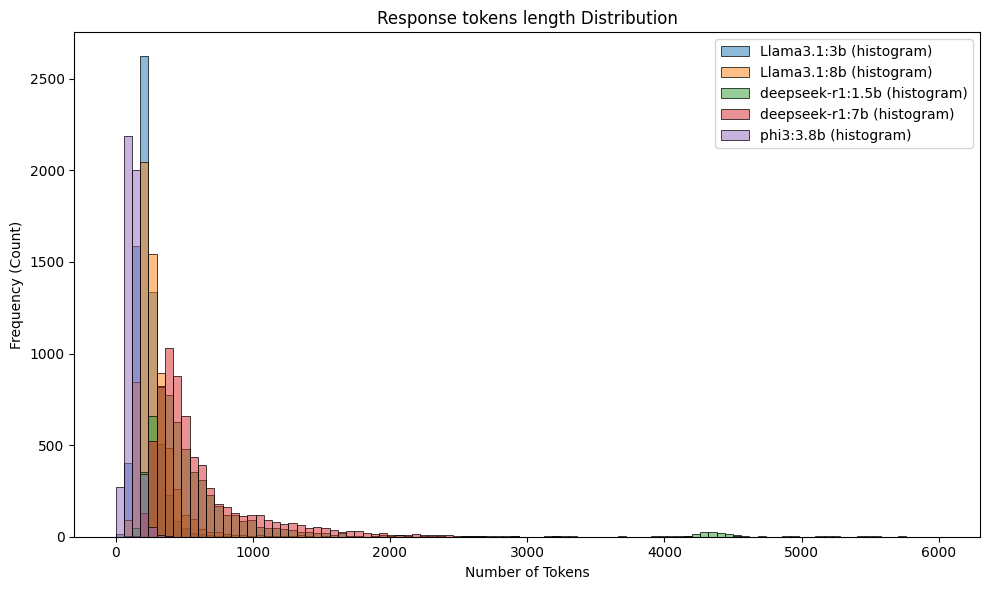

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

for k, v in models_pred.items():
    df = models_pred[k]['df']
    df['response_token_len'] = (
        df[df['contains_answer']]['answer']
        .apply(gemma3_tokenizer.tokenize)
        .apply(len)
    )
    
    # Plot histogram on left y-axis
    sns.histplot(
        df['response_token_len'],
        binrange=(0, 6000),
        bins=100,
        kde=False,
        label=f'{k} (histogram)',
        alpha=0.5,
        ax=ax1
    )

# Configure left y-axis (histogram)
ax1.set_xlabel("Number of Tokens")
ax1.set_ylabel("Frequency (Count)")

# Handle legends
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')

plt.title("Response tokens length Distribution")
plt.tight_layout()
plt.show()


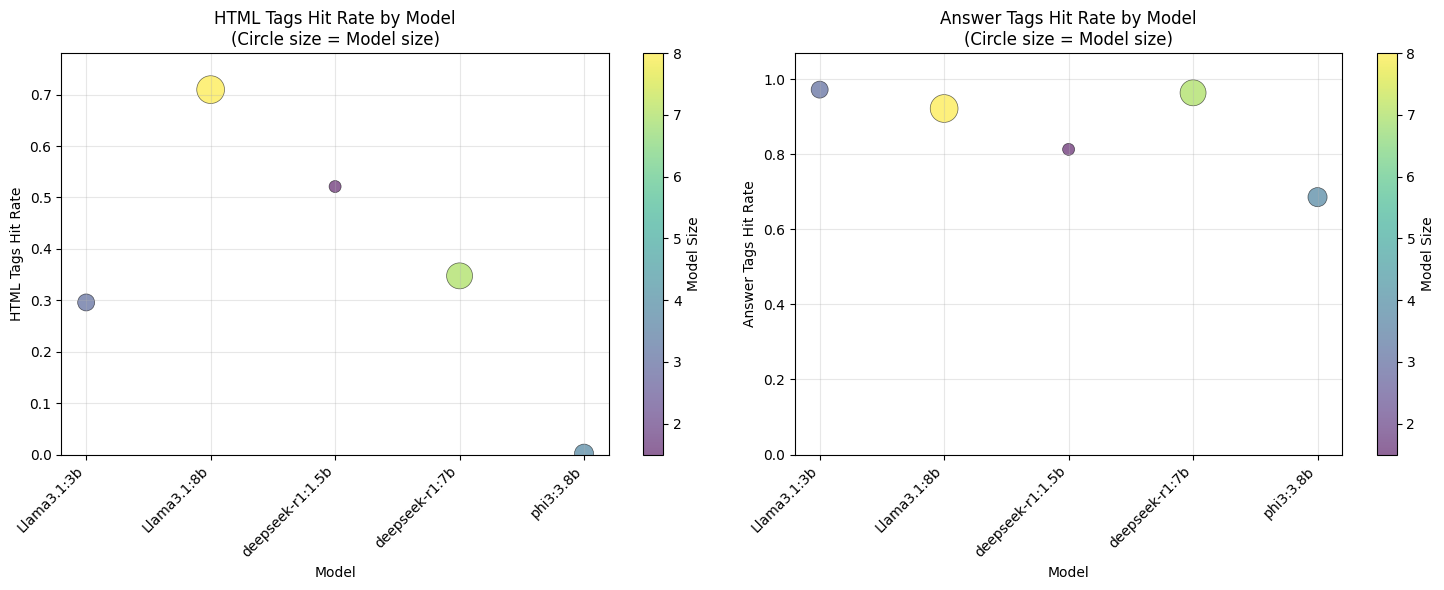

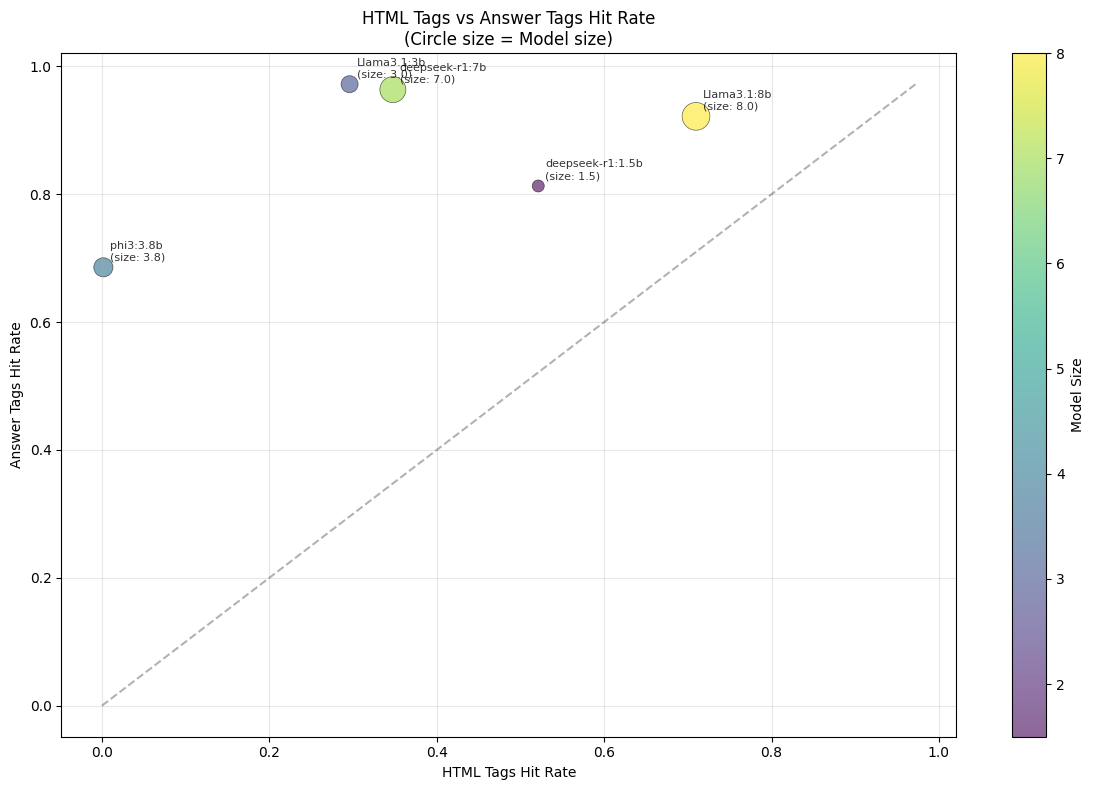

Model Performance Summary (ordered by size):
-----------------------------------------------------------------
Model                     Size     Structure Rate  Extract Rate   
-----------------------------------------------------------------
Llama3.1:3b               3.0      0.296           0.972          
Llama3.1:8b               8.0      0.710           0.922          
deepseek-r1:1.5b          1.5      0.521           0.813          
deepseek-r1:7b            7.0      0.348           0.964          
phi3:3.8b                 3.8      0.002           0.686          


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from your models_pred dictionary
model_names = []
html_hitrates = []
answer_hitrates = []
model_sizes = []

for key, data in models_pred.items():
    model_names.append(key)
    html_hitrates.append(data['html_tags_hitrate'])
    answer_hitrates.append(data['answer_tags_hitrate'])
    model_sizes.append(data['size'])

# Convert to numpy arrays for easier manipulation
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)
model_sizes = np.array(model_sizes)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Normalize model sizes for circle sizes (scale them appropriately for visibility)
# You can adjust the scaling factor (e.g., 100, 200) based on your preference
circle_sizes = model_sizes * 50  # Adjust this multiplier as needed

# Plot 1: HTML Tags Hit Rate
scatter1 = ax1.scatter(range(len(model_names)), html_hitrates, 
                      s=circle_sizes, alpha=0.6, c=model_sizes, 
                      cmap='viridis', edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Model')
ax1.set_ylabel('HTML Tags Hit Rate')
ax1.set_title('HTML Tags Hit Rate by Model\n(Circle size = Model size)')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(html_hitrates) * 1.1)

# Add colorbar for model sizes
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Model Size')

# Plot 2: Answer Tags Hit Rate
scatter2 = ax2.scatter(range(len(model_names)), answer_hitrates, 
                      s=circle_sizes, alpha=0.6, c=model_sizes, 
                      cmap='viridis', edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Model')
ax2.set_ylabel('Answer Tags Hit Rate')
ax2.set_title('Answer Tags Hit Rate by Model\n(Circle size = Model size)')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(answer_hitrates) * 1.1)

# Add colorbar for model sizes
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Model Size')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

# Alternative: Single plot comparing both metrics
plt.figure(figsize=(12, 8))

# Create scatter plot with both metrics
plt.scatter(html_hitrates, answer_hitrates, s=circle_sizes, 
           alpha=0.6, c=model_sizes, 
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(size: {model_sizes[i]})", 
                (html_hitrates[i], answer_hitrates[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HTML Tags Hit Rate')
plt.ylabel('Answer Tags Hit Rate') 
plt.title('HTML Tags vs Answer Tags Hit Rate\n(Circle size = Model size)')
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Model Size')

# Add diagonal line for reference (where both rates are equal)
max_val = max(max(html_hitrates), max(answer_hitrates))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal rates')

plt.tight_layout()

# Save as SVG
plt.savefig('model_performance_scatter.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Print summary statistics
print("Model Performance Summary (ordered by size):")
print("-" * 65)
print(f"{'Model':<25} {'Size':<8} {'Structure Rate':<15} {'Extract Rate':<15}")
print("-" * 65)
for i, name in enumerate(model_names):
    print(f"{name:<25} {model_sizes[i]:<8.1f} {html_hitrates[i]:<15.3f} {answer_hitrates[i]:<15.3f}")


In [ ]:
models_pred.keys()


dict_keys(['Llama3.1:3b', 'Llama3.1:8b', 'deepseek-r1:1.5b', 'deepseek-r1:7b', 'phi3:3.8b'])

In [ ]:
models_pred['Llama3.1:3b']['accuracy']


{'Interaction': 0.42285237698081735,
 'Sequence': 0.43084216397099834,
 'Prediction': 0.42467948717948717,
 'Feasibility': 0.43673469387755104,
 'Average': 0.4280078895463511}

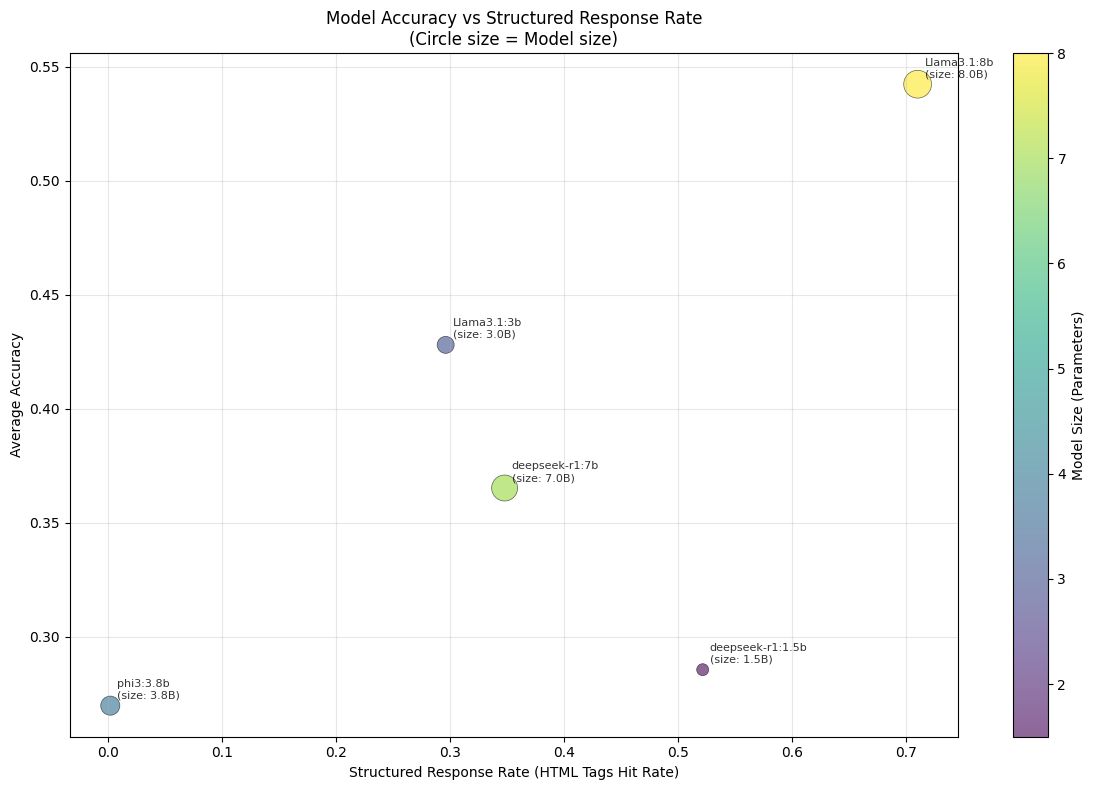

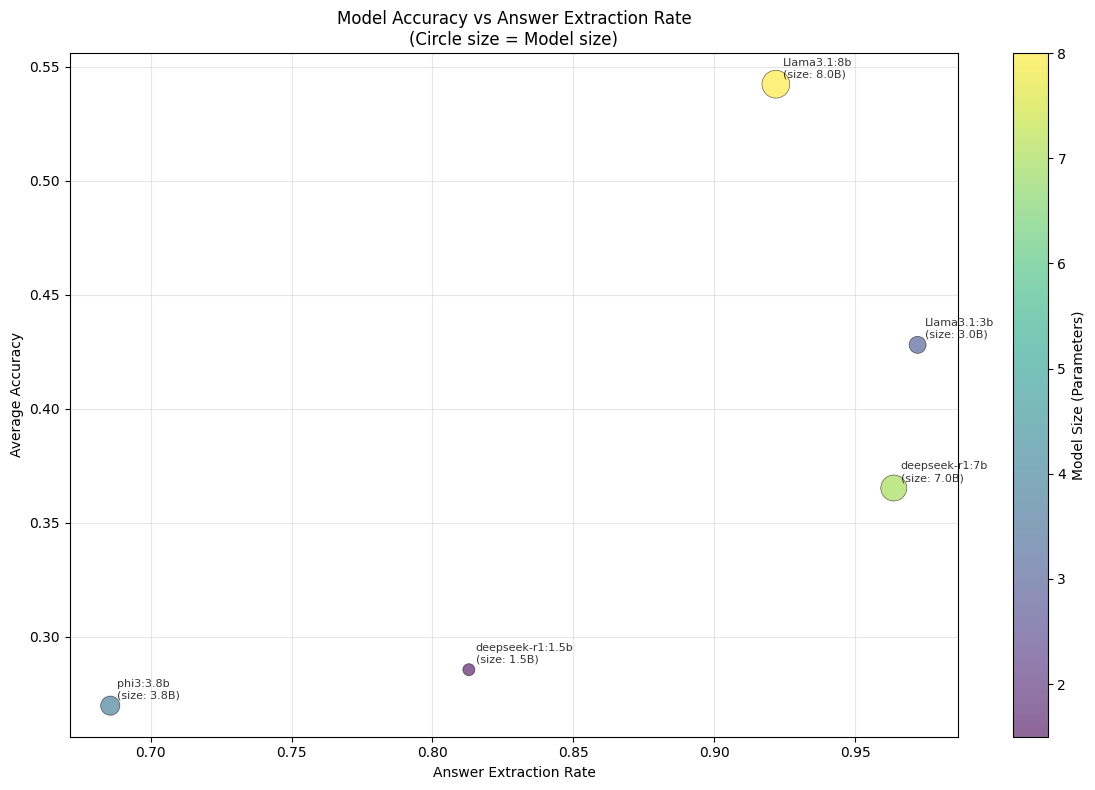

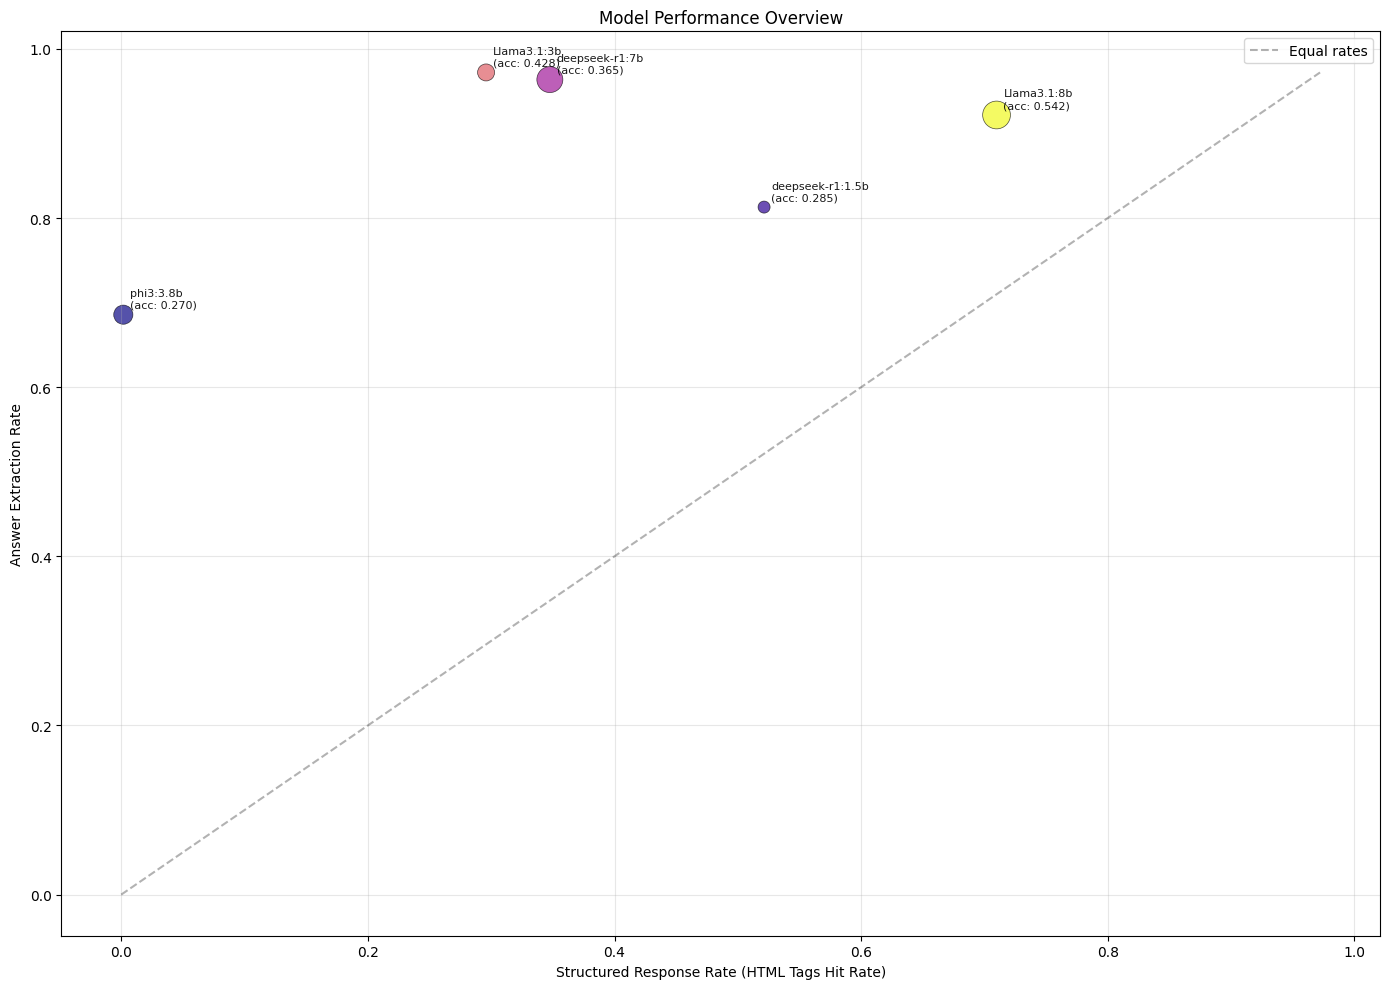

Model Performance Summary with Accuracy:
--------------------------------------------------------------------------------
Model                     Size     Structure Rate  Extract Rate    Accuracy    
--------------------------------------------------------------------------------
Llama3.1:3b               3.0      0.296           0.972           0.428       
Llama3.1:8b               8.0      0.710           0.922           0.542       
deepseek-r1:1.5b          1.5      0.521           0.813           0.285       
deepseek-r1:7b            7.0      0.348           0.964           0.365       
phi3:3.8b                 3.8      0.002           0.686           0.270       

Correlation Analysis:
Structure Rate vs Accuracy: 0.662
Extraction Rate vs Accuracy: 0.693
Model Size vs Accuracy: 0.670


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from your models_pred dictionary
model_names = []
html_hitrates = []
answer_hitrates = []
model_sizes = []
accuracies = []

for key, data in models_pred.items():
    model_names.append(key)
    html_hitrates.append(data['html_tags_hitrate'])
    answer_hitrates.append(data['answer_tags_hitrate'])
    model_sizes.append(data['size'])
    accuracies.append(data['accuracy']['Average'])  # Extract average accuracy

# Convert to numpy arrays for easier manipulation
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)
model_sizes = np.array(model_sizes)
accuracies = np.array(accuracies)

# Create circle sizes based on model size
circle_sizes = model_sizes * 50  # Adjust this multiplier as needed

# Create the accuracy plot similar to the hit rates plot
plt.figure(figsize=(12, 8))

# Create scatter plot with accuracy vs hit rates
plt.scatter(html_hitrates, accuracies, s=circle_sizes,
           alpha=0.6, c=model_sizes, cmap='viridis',
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('Structured Response Rate (HTML Tags Hit Rate)')
plt.ylabel('Average Accuracy')
plt.title('Model Accuracy vs Structured Response Rate\n(Circle size = Model size)')
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Model Size (Parameters)')

plt.tight_layout()

# Save as SVG
plt.savefig('model_accuracy_vs_structure.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Second plot: Accuracy vs Answer Extraction Rate
plt.figure(figsize=(12, 8))

# Create scatter plot with accuracy vs answer hit rates
plt.scatter(answer_hitrates, accuracies, s=circle_sizes,
           alpha=0.6, c=model_sizes, cmap='viridis',
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (answer_hitrates[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('Answer Extraction Rate')
plt.ylabel('Average Accuracy')
plt.title('Model Accuracy vs Answer Extraction Rate\n(Circle size = Model size)')
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Model Size (Parameters)')

plt.tight_layout()

# Save as SVG
plt.savefig('model_accuracy_vs_extraction.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Third plot: 3D-like view showing all three metrics
plt.figure(figsize=(14, 10))

# Create scatter plot with all three metrics
scatter = plt.scatter(html_hitrates, answer_hitrates, s=circle_sizes,
                     alpha=0.7, c=accuracies, cmap='plasma',
                     edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(acc: {accuracies[i]:.3f})", 
                (html_hitrates[i], answer_hitrates[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.9)

plt.xlabel('Structured Response Rate (HTML Tags Hit Rate)')
plt.ylabel('Answer Extraction Rate')
plt.title('Model Performance Overview')
plt.grid(True, alpha=0.3)

# Add diagonal line for reference (where both rates are equal)
max_val = max(max(html_hitrates), max(answer_hitrates))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal rates')
plt.legend()

plt.tight_layout()

# Save as SVG
plt.savefig('model_performance_overview.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Print summary statistics including accuracy
print("Model Performance Summary with Accuracy:")
print("-" * 80)
print(f"{'Model':<25} {'Size':<8} {'Structure Rate':<15} {'Extract Rate':<15} {'Accuracy':<12}")
print("-" * 80)
for i, name in enumerate(model_names):
    print(f"{name:<25} {model_sizes[i]:<8.1f} {html_hitrates[i]:<15.3f} {answer_hitrates[i]:<15.3f} {accuracies[i]:<12.3f}")

# Print correlation analysis
print(f"\nCorrelation Analysis:")
print(f"Structure Rate vs Accuracy: {np.corrcoef(html_hitrates, accuracies)[0,1]:.3f}")
print(f"Extraction Rate vs Accuracy: {np.corrcoef(answer_hitrates, accuracies)[0,1]:.3f}")
print(f"Model Size vs Accuracy: {np.corrcoef(model_sizes, accuracies)[0,1]:.3f}")


In [ ]:
models_pred.keys()


dict_keys(['Llama3.1:3b', 'Llama3.1:8b', 'deepseek-r1:1.5b', 'deepseek-r1:7b', 'phi3:3.8b'])

In [ ]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Normalize model sizes for circle sizes (scale them appropriately for visibility)
# You can adjust the scaling factor (e.g., 100, 200) based on your preference
circle_sizes = model_sizes * 50  # Adjust this multiplier as needed

# Plot 1: HTML Tags Hit Rate
scatter1 = ax1.scatter(range(len(model_names)), html_hitrates, 
                      s=circle_sizes, alpha=0.6, c=model_sizes, 
                      cmap='viridis', edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Model')
ax1.set_ylabel('HTML Tags Hit Rate')
ax1.set_title('HTML Tags Hit Rate by Model\n(Circle size = Model size)')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(html_hitrates) * 1.1)

# Add colorbar for model sizes
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Model Size')

# Plot 2: Answer Tags Hit Rate
scatter2 = ax2.scatter(range(len(model_names)), answer_hitrates, 
                      s=circle_sizes, alpha=0.6, c=model_sizes, 
                      cmap='viridis', edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Model')
ax2.set_ylabel('Answer Tags Hit Rate')
ax2.set_title('Answer Tags Hit Rate by Model\n(Circle size = Model size)')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(answer_hitrates) * 1.1)

# Add colorbar for model sizes
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Model Size')


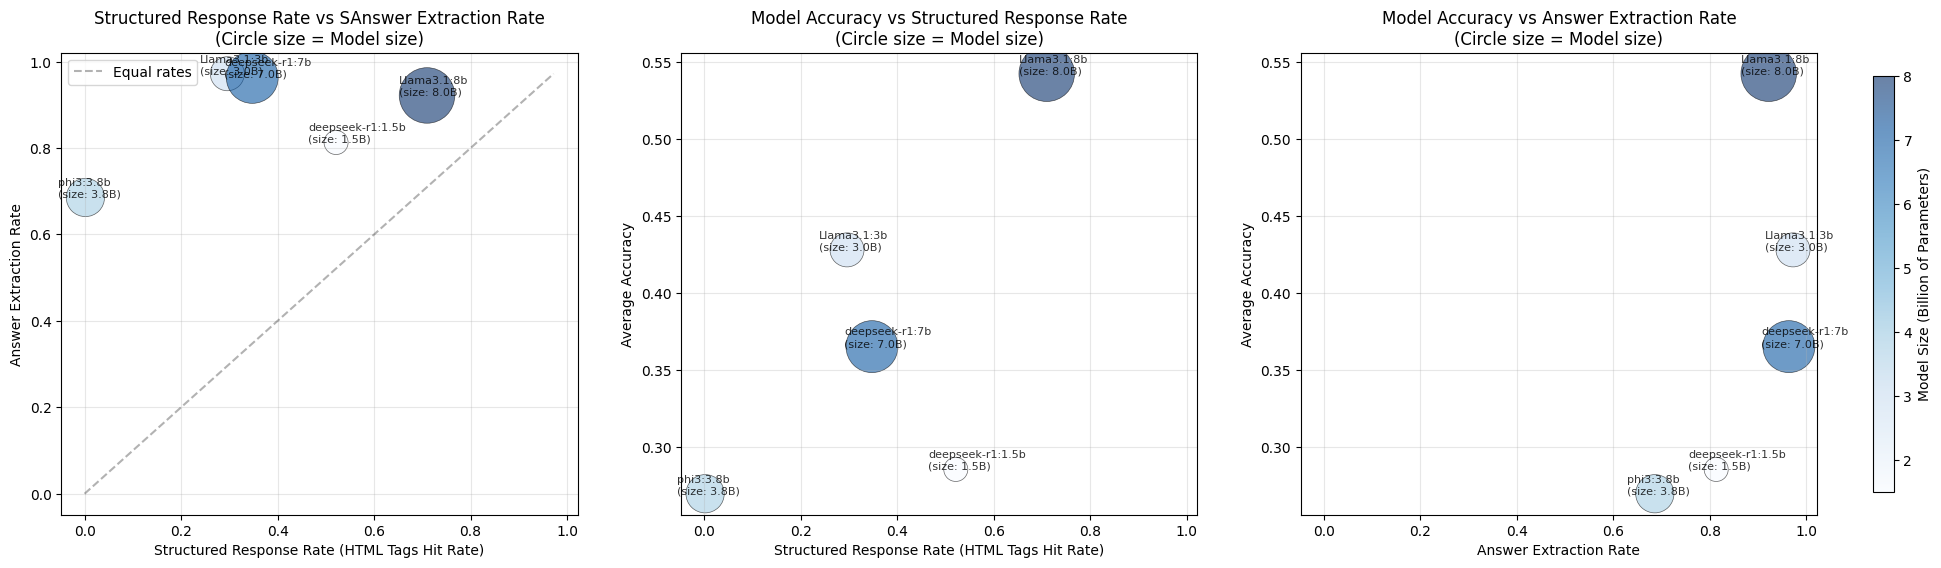

In [484]:
import matplotlib.pyplot as plt
import numpy as np

# Your data extraction code remains the same...

# Create figure with two subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

scatter1 = ax1.scatter(html_hitrates, answer_hitrates, s=circle_sizes, alpha=0.6, 
                      c=model_sizes, cmap='Blues', edgecolors='black', linewidth=0.5)
# Add diagonal line for reference (where both rates are equal)
max_val = max(max(html_hitrates), max(answer_hitrates))
ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal rates')
ax1.legend()

# Create scatter plots
scatter2 = ax2.scatter(html_hitrates, accuracies, s=circle_sizes, alpha=0.6, 
                      c=model_sizes, cmap='Blues', edgecolors='black', linewidth=0.5)

scatter3 = ax3.scatter(answer_hitrates, accuracies, s=circle_sizes, alpha=0.6, 
                      c=model_sizes, cmap='Blues', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax1.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], answer_hitrates[i]), xytext=(-20, 0), 
                textcoords='offset points', fontsize=8, alpha=0.8)    
    ax2.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], accuracies[i]), xytext=(-20, 0), 
                textcoords='offset points', fontsize=8, alpha=0.8)
    ax3.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (answer_hitrates[i], accuracies[i]), xytext=(-20, 0), 
                textcoords='offset points', fontsize=8, alpha=0.8)

x_min = min(min(html_hitrates), min(answer_hitrates)) - 0.05
x_max = max(max(html_hitrates), max(answer_hitrates)) + 0.05
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)
ax3.set_xlim(x_min, x_max)

# Set labels and titles
ax1.set_xlabel('Structured Response Rate (HTML Tags Hit Rate)')
ax1.set_ylabel('Answer Extraction Rate')
ax1.set_title('Structured Response Rate vs SAnswer Extraction Rate\n(Circle size = Model size)')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Structured Response Rate (HTML Tags Hit Rate)')
ax2.set_ylabel('Average Accuracy')
ax2.set_title('Model Accuracy vs Structured Response Rate\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)

ax3.set_xlabel('Answer Extraction Rate')
ax3.set_ylabel('Average Accuracy')
ax3.set_title('Model Accuracy vs Answer Extraction Rate\n(Circle size = Model size)')
ax3.grid(True, alpha=0.3)

# Use subplots_adjust to make room for colorbar while keeping subplots equal
plt.subplots_adjust(right=0.90)

# Add colorbar in the reserved space
cbar = fig.colorbar(scatter1, ax=[ax1, ax2, ax3], shrink=0.9, aspect=20, 
                   fraction=0.026, pad=0.03)
cbar.set_label('Model Size (Billion of Parameters)')

plt.savefig('model_accuracy_vs_extraction.svg', format='svg', bbox_inches='tight', dpi=300)


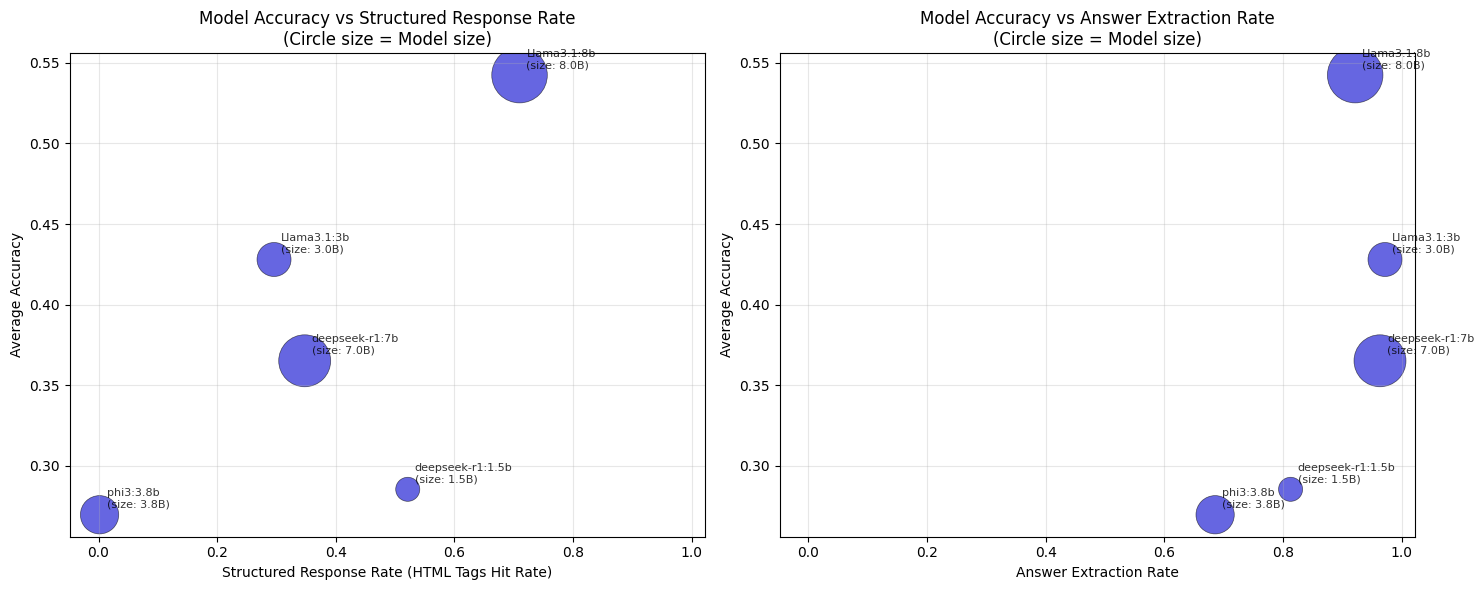

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your data extraction code remains the same...

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Create scatter plots with a single medium blue color
scatter1 = ax1.scatter(html_hitrates, accuracies, s=circle_sizes, alpha=0.6, 
                      c='mediumblue', edgecolors='black', linewidth=0.5)

scatter2 = ax2.scatter(answer_hitrates, accuracies, s=circle_sizes, alpha=0.6, 
                      c='mediumblue', edgecolors='black', linewidth=0.5)

# Add annotations
for i, name in enumerate(model_names):
    ax1.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], accuracies[i]), xytext=(5, 5), 
                textcoords='offset points', fontsize=8, alpha=0.8)
    ax2.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (answer_hitrates[i], accuracies[i]), xytext=(5, 5), 
                textcoords='offset points', fontsize=8, alpha=0.8)

# Set the same x-axis range for both subplots
x_min = min(min(html_hitrates), min(answer_hitrates)) - 0.05
x_max = max(max(html_hitrates), max(answer_hitrates)) + 0.05
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

# Set labels and titles
ax1.set_xlabel('Structured Response Rate (HTML Tags Hit Rate)')
ax1.set_ylabel('Average Accuracy')
ax1.set_title('Model Accuracy vs Structured Response Rate\n(Circle size = Model size)')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Answer Extraction Rate')
ax2.set_ylabel('Average Accuracy')
ax2.set_title('Model Accuracy vs Answer Extraction Rate\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_accuracy_vs_extraction.svg', format='svg', bbox_inches='tight', dpi=300)


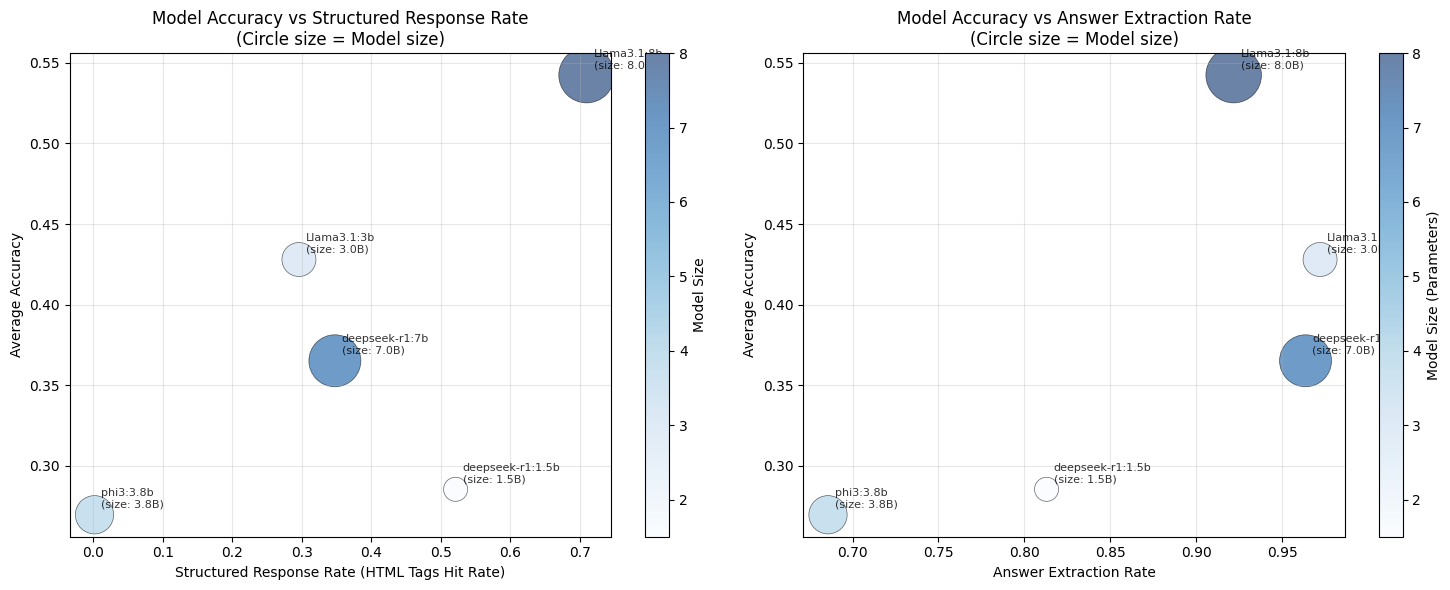

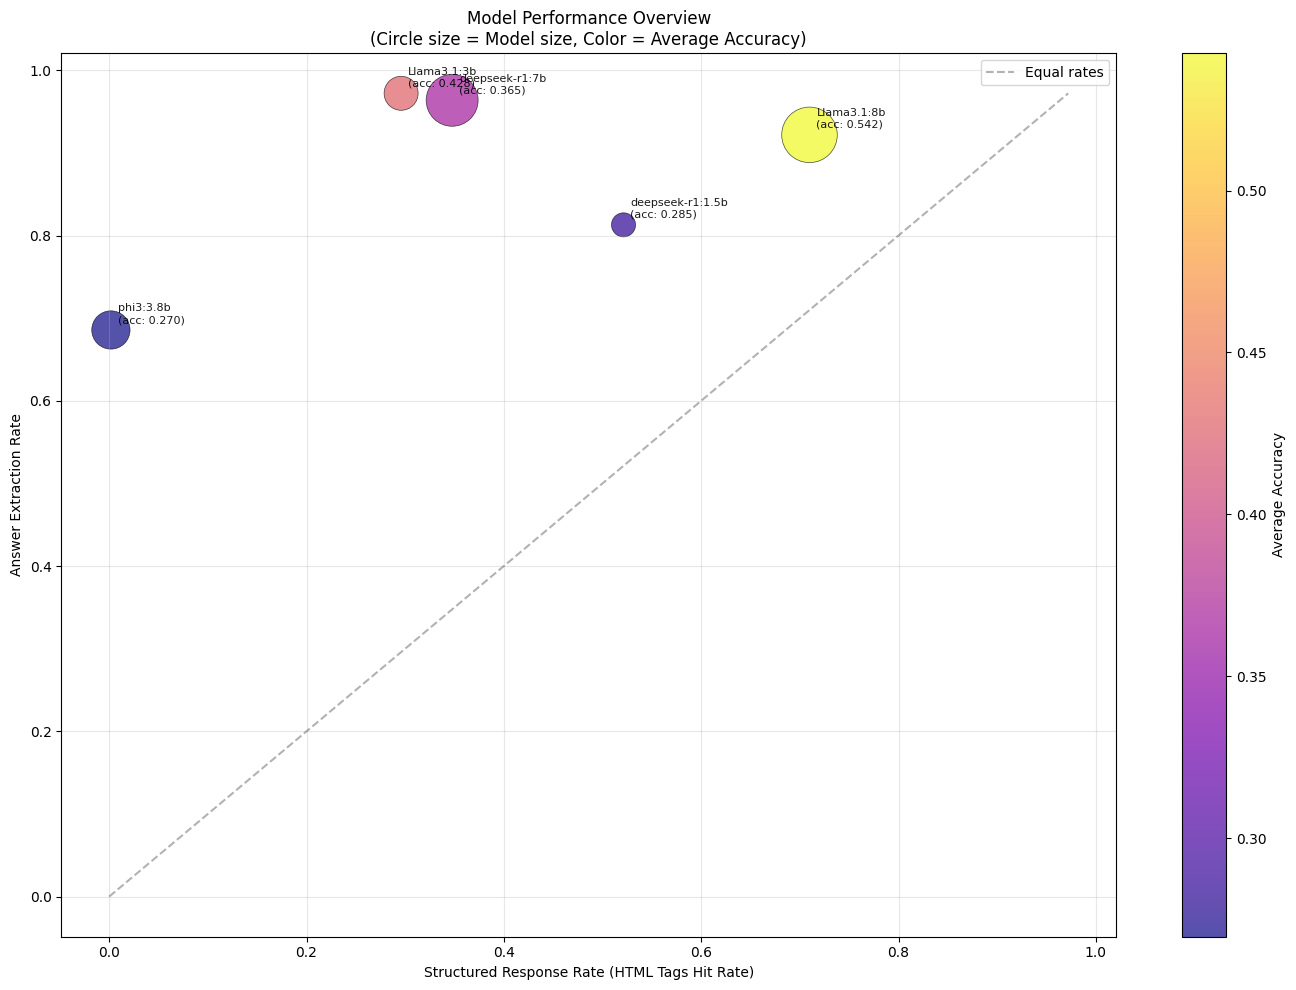

Model Performance Summary with Accuracy:
--------------------------------------------------------------------------------
Model                     Size     Structure Rate  Extract Rate    Accuracy    
--------------------------------------------------------------------------------
Llama3.1:3b               3.0      0.296           0.972           0.428       
Llama3.1:8b               8.0      0.710           0.922           0.542       
deepseek-r1:1.5b          1.5      0.521           0.813           0.285       
deepseek-r1:7b            7.0      0.348           0.964           0.365       
phi3:3.8b                 3.8      0.002           0.686           0.270       

Correlation Analysis:
Structure Rate vs Accuracy: 0.662
Extraction Rate vs Accuracy: 0.693
Model Size vs Accuracy: 0.670


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from your models_pred dictionary
model_names = []
html_hitrates = []
answer_hitrates = []
model_sizes = []
accuracies = []

for key, data in models_pred.items():
    model_names.append(key)
    html_hitrates.append(data['html_tags_hitrate'])
    answer_hitrates.append(data['answer_tags_hitrate'])
    model_sizes.append(data['size'])
    accuracies.append(data['accuracy']['Average'])  # Extract average accuracy

# Convert to numpy arrays for easier manipulation
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)
model_sizes = np.array(model_sizes)
accuracies = np.array(accuracies)

# Create circle sizes based on model size
circle_sizes = model_sizes * 200  # Adjust this multiplier as needed

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Create scatter plot with accuracy vs hit rates
scatter1 = ax1.scatter(html_hitrates, accuracies, s=circle_sizes,
           alpha=0.6, c=model_sizes, cmap='Blues',
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    ax1.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax1.set_xlabel('Structured Response Rate (HTML Tags Hit Rate)')
ax1.set_ylabel('Average Accuracy')
ax1.set_title('Model Accuracy vs Structured Response Rate\n(Circle size = Model size)')
ax1.grid(True, alpha=0.3)

# Add colorbar for model sizes
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Model Size')


# Create scatter plot with accuracy vs answer hit rates
scatter2 = ax2.scatter(answer_hitrates, accuracies, s=circle_sizes,
           alpha=0.6, c=model_sizes, cmap='Blues',
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    ax2.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (answer_hitrates[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax2.set_xlabel('Answer Extraction Rate')
ax2.set_ylabel('Average Accuracy')
ax2.set_title('Model Accuracy vs Answer Extraction Rate\n(Circle size = Model size)')
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter2, ax=ax2)
cbar.set_label('Model Size (Parameters)')

plt.tight_layout()

# Save as SVG
plt.savefig('model_accuracy_vs_extraction.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Third plot: 3D-like view showing all three metrics
plt.figure(figsize=(14, 10))

# Create scatter plot with all three metrics
scatter = plt.scatter(html_hitrates, answer_hitrates, s=circle_sizes,
                     alpha=0.7, c=accuracies, cmap='plasma',
                     edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(acc: {accuracies[i]:.3f})", 
                (html_hitrates[i], answer_hitrates[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.9)

plt.xlabel('Structured Response Rate (HTML Tags Hit Rate)')
plt.ylabel('Answer Extraction Rate')
plt.title('Model Performance Overview\n(Circle size = Model size, Color = Average Accuracy)')
plt.grid(True, alpha=0.3)

# Add colorbar for accuracy
cbar = plt.colorbar(scatter)
cbar.set_label('Average Accuracy')

# Add diagonal line for reference (where both rates are equal)
max_val = max(max(html_hitrates), max(answer_hitrates))
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal rates')
plt.legend()

plt.tight_layout()

# Save as SVG
plt.savefig('model_performance_overview.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Print summary statistics including accuracy
print("Model Performance Summary with Accuracy:")
print("-" * 80)
print(f"{'Model':<25} {'Size':<8} {'Structure Rate':<15} {'Extract Rate':<15} {'Accuracy':<12}")
print("-" * 80)
for i, name in enumerate(model_names):
    print(f"{name:<25} {model_sizes[i]:<8.1f} {html_hitrates[i]:<15.3f} {answer_hitrates[i]:<15.3f} {accuracies[i]:<12.3f}")

# Print correlation analysis
print(f"\nCorrelation Analysis:")
print(f"Structure Rate vs Accuracy: {np.corrcoef(html_hitrates, accuracies)[0,1]:.3f}")
print(f"Extraction Rate vs Accuracy: {np.corrcoef(answer_hitrates, accuracies)[0,1]:.3f}")
print(f"Model Size vs Accuracy: {np.corrcoef(model_sizes, accuracies)[0,1]:.3f}")


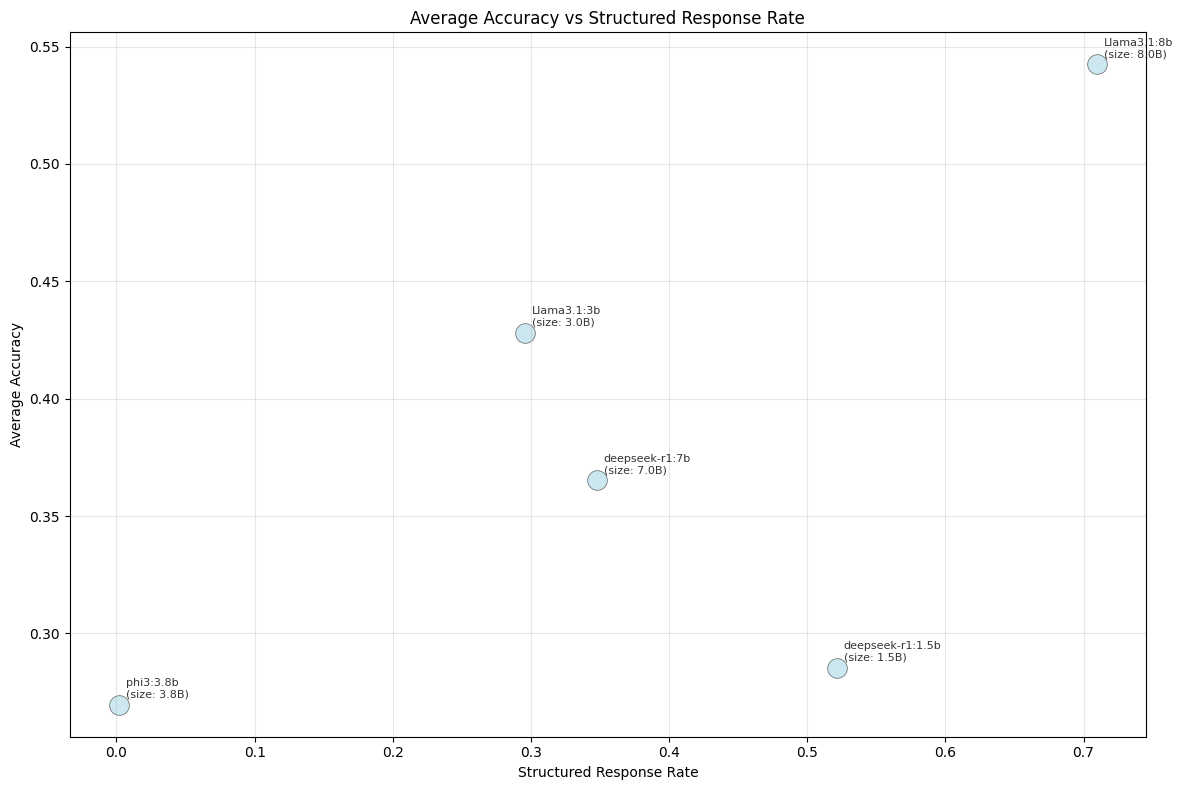

Model Performance Summary with Accuracy:
--------------------------------------------------------------------------------
Model                     Size     Structure Rate  Extract Rate    Accuracy    
--------------------------------------------------------------------------------
Llama3.1:3b               3.0      0.296           0.972           0.428       
Llama3.1:8b               8.0      0.710           0.922           0.542       
deepseek-r1:1.5b          1.5      0.521           0.813           0.285       
deepseek-r1:7b            7.0      0.348           0.964           0.365       
phi3:3.8b                 3.8      0.002           0.686           0.270       


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from your models_pred dictionary
model_names = []
html_hitrates = []
answer_hitrates = []
model_sizes = []
accuracies = []

for key, data in models_pred.items():
    model_names.append(key)
    html_hitrates.append(data['html_tags_hitrate'])
    answer_hitrates.append(data['answer_tags_hitrate'])
    model_sizes.append(data['size'])
    accuracies.append(data['accuracy']['Average'])  # Extract average accuracy

# Convert to numpy arrays for easier manipulation
html_hitrates = np.array(html_hitrates)
answer_hitrates = np.array(answer_hitrates)
model_sizes = np.array(model_sizes)
accuracies = np.array(accuracies)

# Set uniform circle size
circle_size = 200  # Fixed size for all circles

# Create the accuracy plot similar to your preferred hit rates plot
plt.figure(figsize=(12, 8))

# Create scatter plot with accuracy vs structured response rate
plt.scatter(html_hitrates, accuracies, s=circle_size,
           alpha=0.6, c='lightblue',
           edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, name in enumerate(model_names):
    plt.annotate(f"{name}\n(size: {model_sizes[i]:.1f}B)", 
                (html_hitrates[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('Structured Response Rate')
plt.ylabel('Average Accuracy')
plt.title('Average Accuracy vs Structured Response Rate')
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save as SVG
plt.savefig('model_accuracy_vs_structure.svg', format='svg', bbox_inches='tight', dpi=300)

plt.show()

# Print summary statistics
print("Model Performance Summary with Accuracy:")
print("-" * 80)
print(f"{'Model':<25} {'Size':<8} {'Structure Rate':<15} {'Extract Rate':<15} {'Accuracy':<12}")
print("-" * 80)
for i, name in enumerate(model_names):
    print(f"{name:<25} {model_sizes[i]:<8.1f} {html_hitrates[i]:<15.3f} {answer_hitrates[i]:<15.3f} {accuracies[i]:<12.3f}")


In [23]:
# Inner join - keeps only indices present in both series

ans_df.rename(columns={'text': 'pred_text'}, inplace=True)
eval_df = gt_df.join(
    ans_df, 
    how='inner' # we account also for samples without answers
)

eval_df.shape


(6543, 4)

In [24]:
eval_df['edit_distance'] = eval_df.apply(func=lambda row: edit_distance(row['text'], row['pred_text']), axis=1)

eval_df['edit_distance'].sort_values(ascending=True).value_counts(sort=False)


0     3850
2       20
3       36
4      386
5      288
6      251
7      564
8      329
9       50
10     109
11     114
12     129
13     117
14      61
15      61
16      33
17      34
18      28
19      29
20      26
21      13
22       9
23       6
Name: edit_distance, dtype: int64

In [25]:
eval_df[(eval_df['edit_distance'] > 0) & (eval_df['edit_distance'] < 3)]


,choices,num,text,pred_text,edit_distance
id,,,,,
Interaction_T1_3745,"{'0': 'The door.', '1': 'The box.', '2': 'The ...",3,The book.,The box.,2
Interaction_T1_7146,"{'0': 'The bag.', '1': 'The box.', '2': 'The c...",1,The box.,The bag.,2
Sequence_T1_1586,"{'0': 'The book.', '1': 'The box.', '2': 'The ...",0,The book.,The box.,2
Sequence_T1_2084,"{'0': 'The book.', '1': 'The broom.', '2': 'Th...",0,The book.,The broom.,2
Sequence_T1_2567,"{'0': 'The closet/cabinet.', '1': 'The door.',...",2,The book.,The door.,2
Sequence_T1_7685,"{'0': 'The box.', '1': 'The bag.', '2': 'The p...",0,The box.,The bag.,2
Sequence_T2_904,"{'0': 'The book.', '1': 'The box.', '2': 'The ...",0,The book.,The box.,2
Sequence_T2_1500,"{'0': 'The box.', '1': 'The window.', '2': 'Th...",0,The box.,The bed.,2
Sequence_T2_1975,"{'0': 'The closet/cabinet.', '1': 'The door.',...",2,The book.,The door.,2


In [26]:
def accuracy(eval_df, on_what='text'):
    hits_text = (eval_df[f'pred_{on_what}'] == eval_df[on_what]).sum()
    

    return hits_text/eval_df.shape[0]


In [27]:
text_acc = accuracy(eval_df)

print(f"Text Accuracy: {text_acc:.2%}")


Text Accuracy: 58.84%


In [28]:
eval_df[eval_df['text'] == eval_df['pred_text']]


,choices,num,text,pred_text,edit_distance
id,,,,,
Interaction_T1_13,"{'0': 'The closet/cabinet.', '1': 'The blanket...",2,The clothes.,The clothes.,0
Interaction_T1_14,"{'0': 'The blanket.', '1': 'The table.', '2': ...",2,The clothes.,The clothes.,0
Interaction_T1_31,"{'0': 'The pillow.', '1': 'The bag.', '2': 'Th...",2,The clothes.,The clothes.,0
Interaction_T1_32,"{'0': 'The food.', '1': 'The shoe.', '2': 'The...",1,The shoe.,The shoe.,0
Interaction_T1_43,"{'0': 'The box.', '1': 'The pillow.', '2': 'Th...",3,The clothes.,The clothes.,0
...,...,...,...,...,...
Feasibility_T6_1448,"{'0': 'Put down the laptop.', '1': 'Tidy up th...",0,Put down the laptop.,Put down the laptop.,0
Feasibility_T6_1449,"{'0': 'Throw the towel.', '1': 'Close the refr...",2,Put down the laptop.,Put down the laptop.,0
Feasibility_T6_1455,"{'0': 'Throw the bag.', '1': 'Wash the table.'...",1,Wash the table.,Wash the table.,0


check if the equality with NA result in a false or is skipped

In [29]:
real_acc = accuracy(eval_df) * eval_df.shape[0] / gt_df.shape[0]

print(f"Real Accuracy: {real_acc:.2%}")


Real Accuracy: 54.24%


In [30]:
def print_acc(eval_df, acc_fn):
    print(f"{'Question type':<15}{'Total':^15}{'Accuracy':^10}\n")

    total = eval_df.index.str.startswith('Interaction').sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith('Interaction')])
    print(f"{'Interaction':<15}{total:^15}{acc:^10.2%}")

    total = eval_df.index.str.startswith('Sequence').sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith('Sequence')])
    print(f"{'Sequence':<15}{total:^15}{acc:^10.2%}")

    total = eval_df.index.str.startswith('Prediction').sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith('Prediction')])
    print(f"{'Prediction':<15}{total:^15}{acc:^10.2%}")

    total = eval_df.index.str.startswith('Feasibility').sum()
    acc = acc_fn(eval_df[eval_df.index.str.startswith('Feasibility')])
    print(f"{'Feasibility':<15}{total:^15}{acc:^10.2%}")


In [31]:
print_acc(eval_df, lambda x: accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction         2245        57.91%  
Sequence            3252        59.04%  
Prediction           605        61.16%  
Feasibility          441        58.96%  


In [32]:
index_intersect = predictions_df[html_tags_mask].index.intersection(eval_df.index)
print_acc(eval_df.loc[index_intersect], accuracy)


Question type       Total      Accuracy 

Interaction         1749        61.64%  
Sequence            2477        61.24%  
Prediction           447        64.43%  
Feasibility          365        60.55%  


In [33]:
# % of answers conforming to template per category

def print_ans_perc(eval_df, gt_df):
    print(f"{'Question type':<15}{'Total':^15}{'Answered':^10}\n")

    total = gt_df.index.str.startswith('Interaction').sum()
    acc = len(gt_df.index.intersection(eval_df[eval_df.index.str.startswith('Interaction')].index))/total
    print(f"{'Interaction':<15}{total:^15}{acc:^10.2%}")

    total = gt_df.index.str.startswith('Sequence').sum()
    acc = len(gt_df.index.intersection(eval_df[eval_df.index.str.startswith('Sequence')].index))/total
    print(f"{'Sequence':<15}{total:^15}{acc:^10.2%}")

    total = gt_df.index.str.startswith('Prediction').sum()
    acc = len(gt_df.index.intersection(eval_df[eval_df.index.str.startswith('Prediction')].index))/total
    print(f"{'Prediction':<15}{total:^15}{acc:^10.2%}")

    total = gt_df.index.str.startswith('Feasibility').sum()
    acc = len(gt_df.index.intersection(eval_df[eval_df.index.str.startswith('Feasibility')].index))/total
    print(f"{'Feasibility':<15}{total:^15}{acc:^10.2%}")

    total = gt_df.shape[0]
    acc = eval_df.shape[0]/total
    print(f"{'Overall':<15}{total:^15}{acc:^10.2%}")

print_ans_perc(eval_df, gt_df)


Question type       Total      Answered 

Interaction         2398        93.62%  
Sequence            3586        90.69%  
Prediction           624        96.96%  
Feasibility          490        90.00%  
Overall             7098        92.18%  


In [34]:
eval_df.shape


(6543, 5)

In [35]:
gt_df.shape


(7098, 3)

In [36]:
eval_df.shape[0]/gt_df.shape[0]


0.9218089602704987